# 📘 CIFAR-10 Image Classification — ANN vs CNN
## Celebal Technologies Internship | Week 4 Assignment


---

**Objective:** Build, train, and **analyze performance** of image classifiers using multiple architectures and training strategies:

| # | Model | Architecture Type | Key Strategy |
|---|-------|------------------|--------------|
| 1 | **ANN** | Fully Connected (Dense only) | Baseline — flat vector input |
| 2 | **CNN** | 3-Block Convolutional Network | Spatial feature extraction + BatchNorm |
| 3 | **CNN + Augmentation** | Same CNN + Data Augmentation | Generalization via augmented training |
| 4 | **Deep CNN** | 4-Block Deeper Network | Increased depth + wider dense head |

**Dataset:** CIFAR-10 — 60,000 color images (32×32×3), 10 classes

---
### 📦 CIFAR-10 Classes
| Index | Class | Index | Class |
|-------|-------|-------|-------|
| 0 | Airplane | 5 | Dog |
| 1 | Automobile | 6 | Frog |
| 2 | Bird | 7 | Horse |
| 3 | Cat | 8 | Ship |
| 4 | Deer | 9 | Truck |

## 📌 Section 1: Imports & Setup

**Libraries used:**
- `tensorflow / keras` — Deep learning framework
- `matplotlib` — Visualization of images and training curves
- `numpy` — Array operations
- `pandas` — Tabular comparison of results
- `seaborn` — Confusion matrix heatmap
- `sklearn` — Classification report, confusion matrix

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("GPU Available:", len(tf.config.list_physical_devices('GPU')) > 0)

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.20.0
GPU Available: True


## 📌 Section 2: Load & Explore Dataset

CIFAR-10 is built into Keras. Each image is a **32×32 grid of pixels**, where each pixel has **3 values (R, G, B)** ranging from 0–255.

- `x_train` shape: (50000, 32, 32, 3)
- `y_train` shape: (50000, 1) — integer labels 0–9

> 💡 **Why 32×32×3?** Width=32, Height=32, Channels=3 (RGB). Total pixels per image = 3072.

In [5]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("=== Dataset Info ===")
print(f"Train images: {x_train.shape}  | Train labels: {y_train.shape}")
print(f"Test  images: {x_test.shape}   | Test  labels: {y_test.shape}")
print(f"Pixel range: [{x_train.min()}, {x_train.max()}]")
print(f"Classes: {class_names}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
=== Dataset Info ===
Train images: (50000, 32, 32, 3)  | Train labels: (50000, 1)
Test  images: (10000, 32, 32, 3)   | Test  labels: (10000, 1)
Pixel range: [0, 255]
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


### 🖼️ Visualize Sample Images (2 per class)

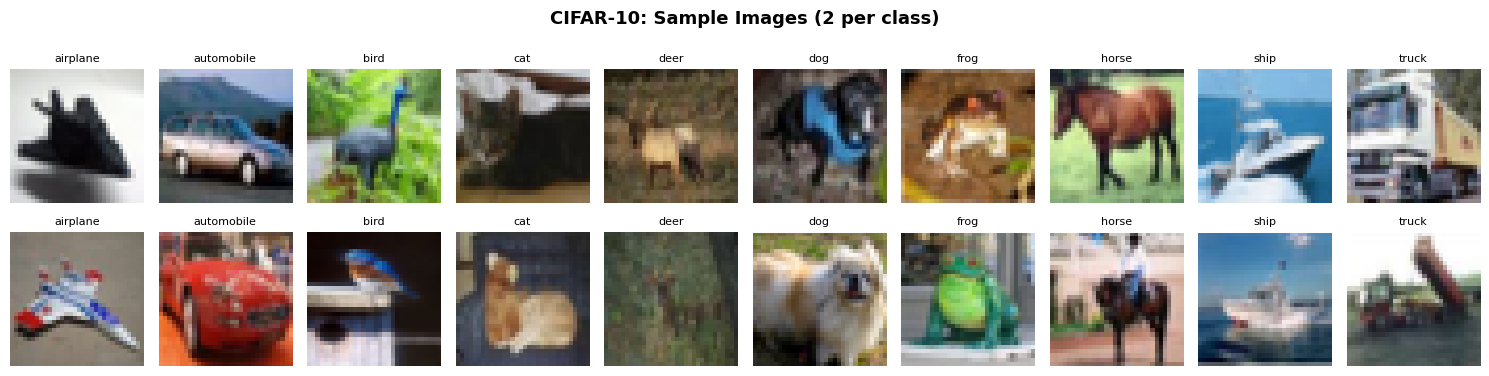

In [6]:
fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for class_idx in range(10):
    indices = np.where(y_train.flatten() == class_idx)[0][:2]
    for row, idx in enumerate(indices):
        axes[row, class_idx].imshow(x_train[idx])
        axes[row, class_idx].set_title(class_names[class_idx], fontsize=8)
        axes[row, class_idx].axis('off')
plt.suptitle('CIFAR-10: Sample Images (2 per class)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 📊 Class Distribution Check

Always verify class balance before training. Imbalanced data can bias the model.

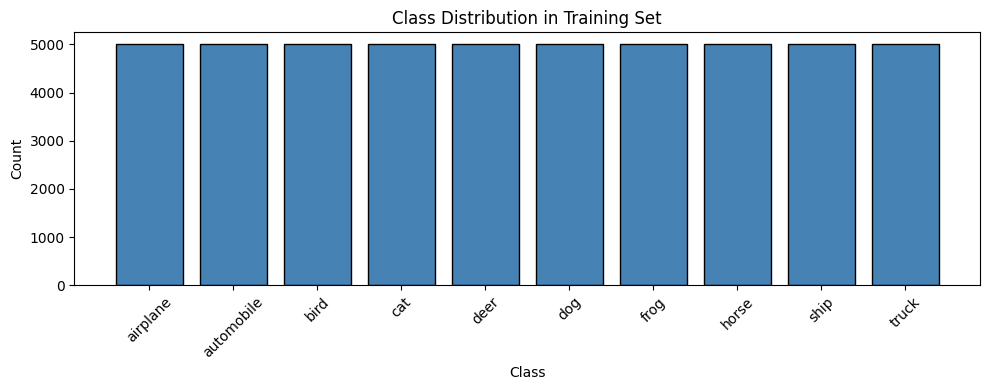

Class counts: {'airplane': np.int64(5000), 'automobile': np.int64(5000), 'bird': np.int64(5000), 'cat': np.int64(5000), 'deer': np.int64(5000), 'dog': np.int64(5000), 'frog': np.int64(5000), 'horse': np.int64(5000), 'ship': np.int64(5000), 'truck': np.int64(5000)}


In [7]:
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(10, 4))
plt.bar(class_names, counts, color='steelblue', edgecolor='black')
plt.title('Class Distribution in Training Set')
plt.ylabel('Count')
plt.xlabel('Class')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("Class counts:", dict(zip(class_names, counts)))

## 📌 Section 3: Preprocessing

### Step 3.1 — Normalize Pixel Values
**Why normalize?** Neural networks train better when inputs are in range [0, 1].
- Raw pixel values: 0–255
- After normalization: 0.0–1.0
- Formula: `x_norm = x / 255.0`

### Step 3.2 — Flatten for ANN
ANN needs a **1D input vector**. We reshape (32, 32, 3) → (3072,).
CNN uses the **original 3D shape** (32, 32, 3).

> ⚠️ **Key Insight:** Flattening destroys spatial information (which pixel is next to which). This is why ANN performs worse on images — it loses the 2D structure.

In [8]:
# Normalize
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm  = x_test.astype('float32') / 255.0

# Flatten for ANN  (32x32x3 = 3072 features)
x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat  = x_test_norm.reshape(len(x_test_norm), -1)

print("For ANN  — Input shape:", x_train_flat.shape)
print("For CNN  — Input shape:", x_train_norm.shape)

For ANN  — Input shape: (50000, 3072)
For CNN  — Input shape: (50000, 32, 32, 3)


## 📌 Section 4: Model 1 — ANN (Artificial Neural Network)

### Architecture Overview
```
Input (3072,) → Dense(512, ReLU) → Dropout(0.3) → Dense(256, ReLU) → Dropout(0.2) → Dense(10, Softmax)
```

| Layer | Type | Units | Activation | Purpose |
|-------|------|-------|------------|---------|
| 1 | Dense | 512 | ReLU | Learn high-level features from flat pixels |
| 2 | Dropout | — | — | Prevent overfitting (30% neurons dropped) |
| 3 | Dense | 256 | ReLU | Refine learned representations |
| 4 | Dropout | — | — | Additional regularization (20%) |
| 5 | Dense | 10 | Softmax | Output probability for each of 10 classes |

### Why Softmax at Output?
Softmax converts raw scores (logits) into **probabilities that sum to 1**.
The class with highest probability is the predicted class.

### Loss Function: `sparse_categorical_crossentropy`
Used when labels are integers (0–9), not one-hot encoded.

> ⚠️ **ANN Limitation:** Since input is flattened to 3072 values, the network has **no concept of spatial proximity** — pixel (0,0) and pixel (31,31) are treated equally, even though they are far apart in the image.

In [9]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
], name='ANN_Model')

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "ANN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

### 🏋️ Train ANN

**Hyperparameters:**
- `epochs=15` — Full passes through training data
- `batch_size=64` — Process 64 images per gradient update
- `validation_split=0.1` — Reserve 10% for validation

**EarlyStopping:** Stops training if val_loss doesn't improve for 3 epochs → prevents overfitting.

In [10]:
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=15,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.2483 - loss: 2.0291 - val_accuracy: 0.3192 - val_loss: 1.8997
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2940 - loss: 1.9057 - val_accuracy: 0.3056 - val_loss: 1.8749
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3103 - loss: 1.8620 - val_accuracy: 0.3580 - val_loss: 1.8063
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3273 - loss: 1.8373 - val_accuracy: 0.3510 - val_loss: 1.8173
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3328 - loss: 1.8167 - val_accuracy: 0.3778 - val_loss: 1.7635
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3396 - loss: 1.8007 - val_accuracy: 0.3646 - val_loss: 1.7724
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3512 - loss: 1.7824 - val_accuracy: 0.3750 - val_loss: 1.7411
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3543 - loss: 1.7656 - val_accuracy: 0.

### 📈 ANN — Plot Training Curves

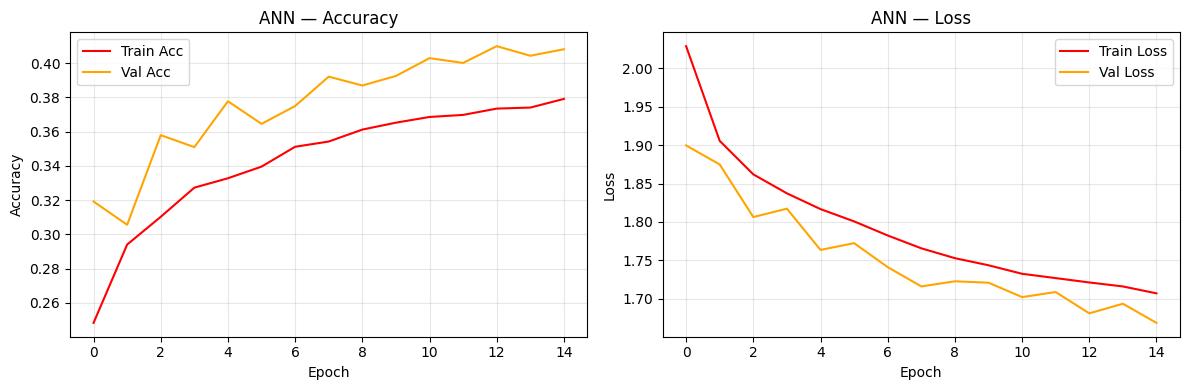

In [11]:
def plot_history(history, model_name, color='blue'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history['accuracy'],     label='Train Acc', color=color)
    ax1.plot(history.history['val_accuracy'], label='Val Acc',   color='orange')
    ax1.set_title(f'{model_name} — Accuracy')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(history.history['loss'],     label='Train Loss', color=color)
    ax2.plot(history.history['val_loss'], label='Val Loss',   color='orange')
    ax2.set_title(f'{model_name} — Loss')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(ann_history, 'ANN', color='red')

In [12]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test, verbose=0)
print(f"ANN Test Accuracy : {ann_test_acc:.4f} ({ann_test_acc*100:.2f}%)")
print(f"ANN Test Loss     : {ann_test_loss:.4f}")

ANN Test Accuracy : 0.4071 (40.71%)
ANN Test Loss     : 1.6564


## 📌 Section 5: Model 2 — CNN (Convolutional Neural Network)

### Why CNN is Better for Images?

| Feature | ANN | CNN |
|---------|-----|-----|
| Input format | Flat vector (3072,) | 3D tensor (32,32,3) |
| Spatial awareness | ❌ None | ✅ Full |
| Local pattern detection | ❌ No | ✅ Yes (via filters) |
| Parameter efficiency | ❌ Many params | ✅ Shared weights |
| Translation invariance | ❌ No | ✅ Via pooling |

### CNN Architecture (3-Block VGG-style)
```
[Block 1] Conv2D(32) → BN → Conv2D(32) → MaxPool → Dropout(0.2)
     ↓
[Block 2] Conv2D(64) → BN → Conv2D(64) → MaxPool → Dropout(0.3)
     ↓
[Block 3] Conv2D(128) → BN → MaxPool → Dropout(0.4)
     ↓
Flatten → Dense(128) → BN → Dropout(0.5) → Dense(10, Softmax)
```

### Key Concepts:
- **Conv2D(32, 3×3):** 32 filters, each 3×3 pixels → learns 32 different features
- **BatchNormalization (BN):** Normalizes layer outputs → faster, stable training
- **MaxPooling2D(2×2):** Reduces spatial size by half → fewer params, translational invariance
- **Double Conv per block:** Like VGG — two consecutive convolutions before pooling gives richer features
- **Dropout:** Randomly disables neurons during training → prevents overfitting

In [13]:
cnn_model = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.2),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),

    # Block 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.4),

    # Classifier Head
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
], name='CNN_Model')

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 404,394 (1.54 MB)

 Trainable params: 403,690 (1.54 MB)

 Non-trainable params: 704 (2.75 KB)

### 🏋️ Train CNN

We add `ReduceLROnPlateau` — automatically reduces learning rate when validation loss plateaus.
This fine-tunes the optimizer to escape local minima.

In [16]:
early_stop_cnn = callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop_cnn, reduce_lr],
    verbose=1
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.3967 - loss: 1.7681 - val_accuracy: 0.5304 - val_loss: 1.3041 - learning_rate: 0.0010
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5703 - loss: 1.2056 - val_accuracy: 0.6058 - val_loss: 1.0881 - learning_rate: 0.0010
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6385 - loss: 1.0261 - val_accuracy: 0.6738 - val_loss: 0.9291 - learning_rate: 0.0010
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6756 - loss: 0.9317 - val_accuracy: 0.7040 - val_loss: 0.8521 - learning_rate: 0.0010
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7005 - loss: 0.8595 - val_accuracy: 0.7304 - val_loss: 0.7692 - learning_rate: 0.0010
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7235 - loss: 0.7995 - val_accuracy: 0.7482 - val_loss: 0.7174 - learning_rate: 0.0010
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7405 - loss: 0.7532 

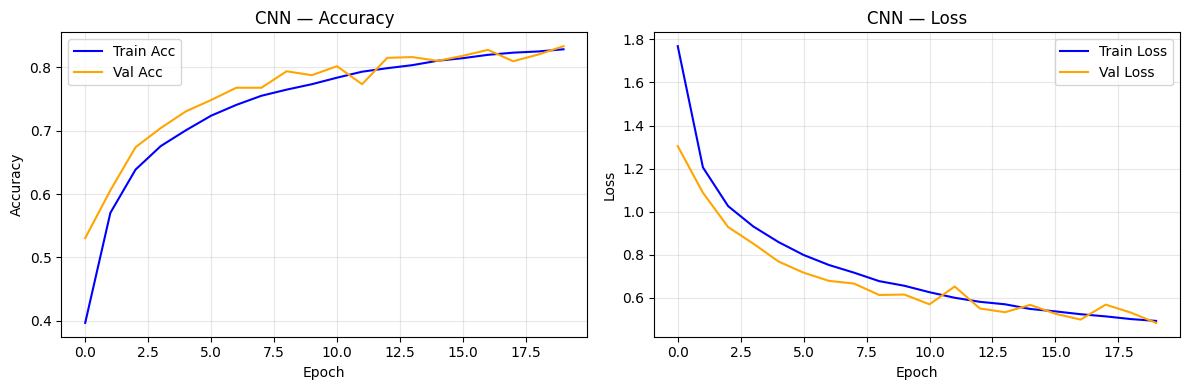

CNN Test Accuracy : 0.8266 (82.66%)
CNN Test Loss     : 0.5038


In [17]:
plot_history(cnn_history, 'CNN', color='blue')

cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"CNN Test Accuracy : {cnn_test_acc:.4f} ({cnn_test_acc*100:.2f}%)")
print(f"CNN Test Loss     : {cnn_test_loss:.4f}")

## 📌 Section 6: Model 3 — CNN + Data Augmentation

### What is Data Augmentation?
Artificially expand training data by applying **random transformations** to images during training.
The model sees more variety → learns to generalize better → less overfitting.

| Augmentation | Effect | Why Useful |
|-------------|--------|-----------|
| `RandomFlip(horizontal)` | Mirror image left-right | Objects look same from both sides |
| `RandomRotation(0.1)` | Rotate ±10% of 360° | Real photos taken at angles |
| `RandomZoom(0.1)` | Zoom in/out by ±10% | Objects appear at different distances |
| `RandomContrast(0.1)` | Vary brightness/contrast | Different lighting conditions |

> 💡 Augmentation layers are **only active during training**, not during evaluation.
> Same architecture as CNN Model 2 — difference is only in **training strategy** (augmented input).

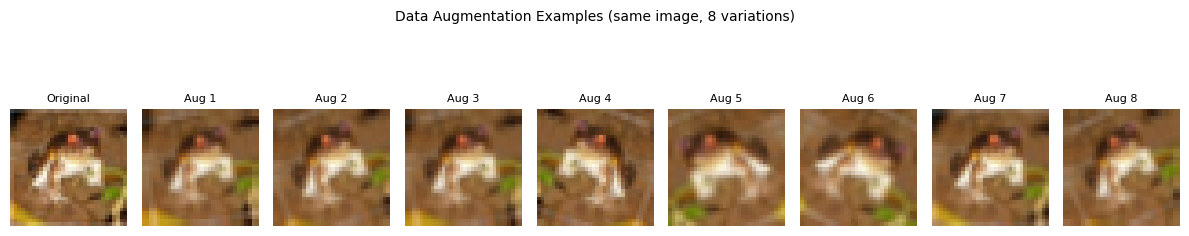

In [18]:
# Visualize augmentation effect
sample_img = x_train_norm[:1]  # shape (1, 32, 32, 3)
aug_layer = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

plt.figure(figsize=(12, 3))
plt.subplot(1, 9, 1)
plt.imshow(sample_img[0])
plt.title('Original', fontsize=8)
plt.axis('off')
for i in range(8):
    aug_img = aug_layer(sample_img, training=True)
    plt.subplot(1, 9, i+2)
    plt.imshow(aug_img[0])
    plt.title(f'Aug {i+1}', fontsize=8)
    plt.axis('off')
plt.suptitle('Data Augmentation Examples (same image, 8 variations)', fontsize=10)
plt.tight_layout()
plt.show()

In [19]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

aug_cnn_model = models.Sequential([
    # Augmentation (only active during training)
    data_augmentation,

    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.2),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),

    # Block 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.4),

    # Classifier Head
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
], name='CNN_Augmented')

aug_cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_cnn_model.summary()

Model: "CNN_Augmented"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.2382 - loss: 2.0671 - val_accuracy: 0.3688 - val_loss: 1.7307 - learning_rate: 0.0010
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.3545 - loss: 1.7457 - val_accuracy: 0.4916 - val_loss: 1.3879 - learning_rate: 0.0010
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.4245 - loss: 1.5742 - val_accuracy: 0.5040 - val_loss: 1.4830 - learning_rate: 0.0010
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.4725 - loss: 1.4630 - val_accuracy: 0.5012 - val_loss: 1.4939 - learning_rate: 0.0010
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.5097 - loss: 1.3663 - val_accuracy: 0.5824 - val_loss: 1.2518 - learning_rate: 0.0010
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.5447 - loss: 1.2929 - val_accuracy: 0.6104 - val_loss: 1.1568 - learning_rate: 0.0010
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.5661 - l

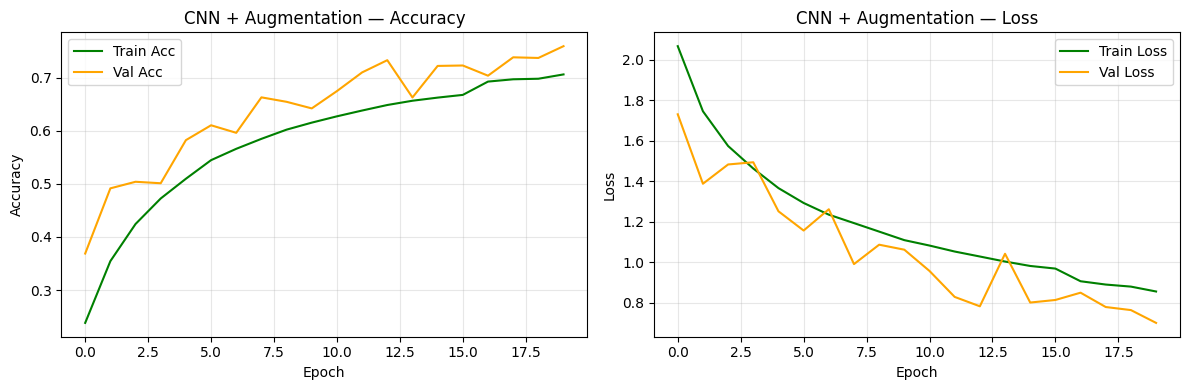

CNN+Aug Test Accuracy : 0.7483 (74.83%)
CNN+Aug Test Loss     : 0.7169


In [20]:
early_stop_aug = callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)
reduce_lr_aug = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop_aug, reduce_lr_aug],
    verbose=1
)

plot_history(aug_history, 'CNN + Augmentation', color='green')

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"CNN+Aug Test Accuracy : {aug_test_acc:.4f} ({aug_test_acc*100:.2f}%)")
print(f"CNN+Aug Test Loss     : {aug_test_loss:.4f}")

## 📌 Section 7: Model 4 — Deep CNN (New Architecture)

### Why a New Architecture?
Models 2 and 3 shared the **same architecture** — CNN + Aug only changed the training strategy.
To truly compare **across architectures**, we now build a **genuinely deeper and wider network**.

### Architectural Differences vs CNN (Model 2)

| Feature | CNN (Model 2) | Deep CNN (Model 4) |
|---------|--------------|-------------------|
| Conv Blocks | 3 blocks | **4 blocks** |
| Filters per block | 32 → 64 → 128 | 32 → 64 → 128 → **256** |
| Dense head width | 128 neurons | **256 neurons** |
| Total depth | Shallower | **Deeper** |
| Data Augmentation | No | **Yes** (built-in) |
| Expected accuracy | ~72–78% | **~80–85%** |

### Deep CNN Architecture
```
[Block 1] Conv2D(32)×2 → BN → MaxPool → Dropout(0.25)
     ↓
[Block 2] Conv2D(64)×2 → BN → MaxPool → Dropout(0.25)
     ↓
[Block 3] Conv2D(128)×2 → BN → MaxPool → Dropout(0.35)
     ↓
[Block 4] Conv2D(256)×2 → BN → MaxPool → Dropout(0.4)   ← NEW BLOCK
     ↓
Flatten → Dense(256) → BN → Dropout(0.5) → Dense(10, Softmax)
```

> 💡 **Key Insight:** Adding a 4th convolutional block (256 filters) allows the network to learn **higher-level abstract features** — not just edges (block 1) and textures (block 2), but object parts (block 3) and whole object patterns (block 4).

In [21]:
deep_cnn_model = models.Sequential([
    # Augmentation (helps deep model generalize better)
    layers.RandomFlip('horizontal', input_shape=(32,32,3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),

    # Block 1 — Edge & color detectors (32 filters)
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Block 2 — Texture patterns (64 filters)
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Block 3 — Object parts (128 filters)
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.35),

    # Block 4 — High-level object representations (256 filters) ← NEW
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.4),

    # Classifier Head — wider than CNN Model 2 (256 vs 128 neurons)
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
], name='Deep_CNN')

deep_cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

deep_cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "Deep_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_2 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_2               │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_2 (RandomZoom)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,440,170 (5.49 MB)

 Trainable params: 1,438,698 (5.49 MB)

 Non-trainable params: 1,472 (5.75 KB)

### 🏋️ Train Deep CNN

Using the same callback strategy as other CNN models for fair comparison.

Epoch 1/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.3405 - loss: 1.9201 - val_accuracy: 0.4476 - val_loss: 1.5141 - learning_rate: 0.0010
Epoch 2/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.4794 - loss: 1.4427 - val_accuracy: 0.4456 - val_loss: 1.7969 - learning_rate: 0.0010
Epoch 3/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.5524 - loss: 1.2527 - val_accuracy: 0.6162 - val_loss: 1.0992 - learning_rate: 0.0010
Epoch 4/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.6010 - loss: 1.1335 - val_accuracy: 0.6036 - val_loss: 1.2278 - learning_rate: 0.0010
Epoch 5/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.6312 - loss: 1.0511 - val_accuracy: 0.6420 - val_loss: 1.1630 - learning_rate: 0.0010
Epoch 6/25
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6548 - loss: 0.9967
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.6593 - los

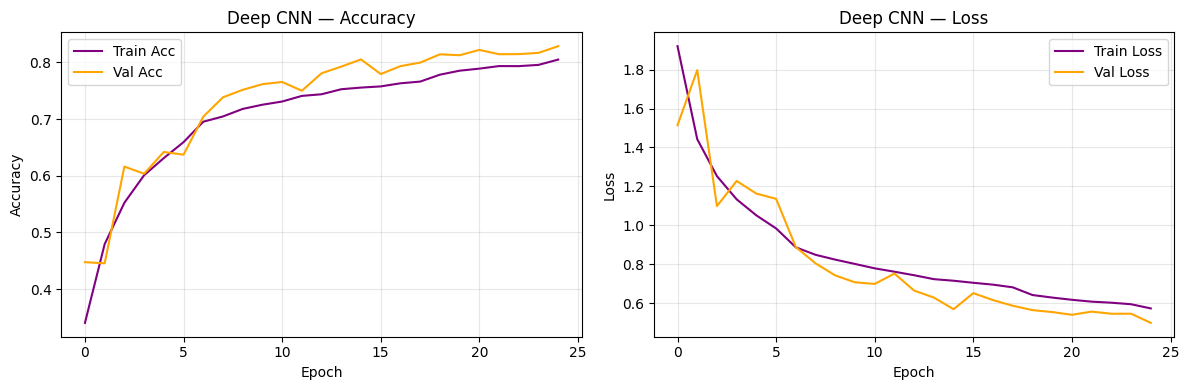

Deep CNN Test Accuracy : 0.8220 (82.20%)
Deep CNN Test Loss     : 0.5312


In [23]:
early_stop_deep = callbacks.EarlyStopping(
    monitor='val_loss', patience=6, restore_best_weights=True
)
reduce_lr_deep = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

deep_history = deep_cnn_model.fit(
    x_train_norm, y_train,
    epochs=25,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop_deep, reduce_lr_deep],
    verbose=1
)

plot_history(deep_history, 'Deep CNN', color='purple')

deep_test_loss, deep_test_acc = deep_cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"Deep CNN Test Accuracy : {deep_test_acc:.4f} ({deep_test_acc*100:.2f}%)")
print(f"Deep CNN Test Loss     : {deep_test_loss:.4f}")

## 📌 Section 8: Performance Analysis

### 8.1 — All Models: Validation Accuracy Comparison

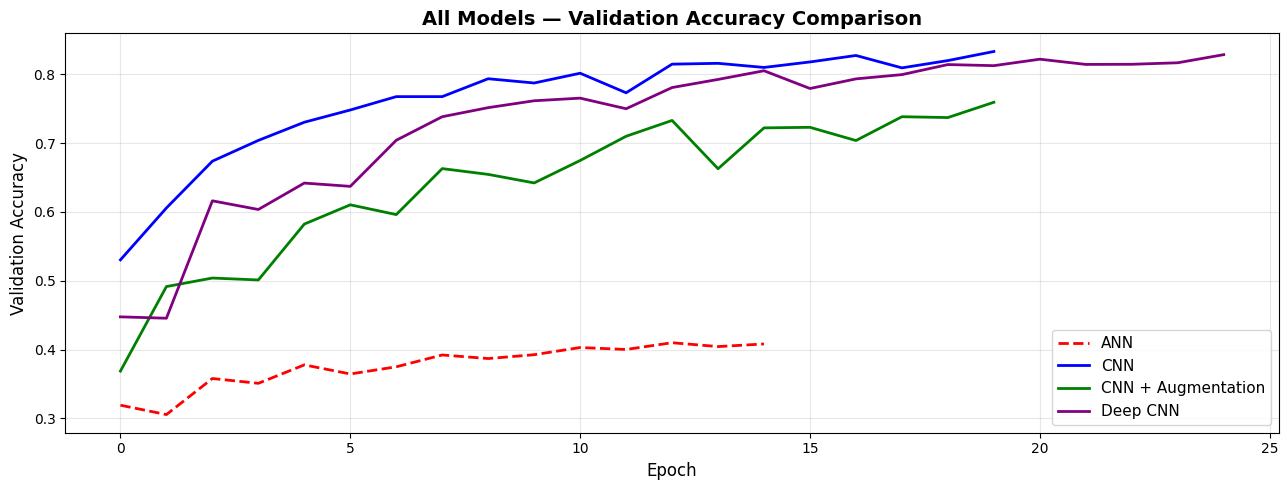

In [24]:
plt.figure(figsize=(13, 5))
plt.plot(ann_history.history['val_accuracy'],     label='ANN',               linestyle='--', color='red',    linewidth=2)
plt.plot(cnn_history.history['val_accuracy'],     label='CNN',               linestyle='-',  color='blue',   linewidth=2)
plt.plot(aug_history.history['val_accuracy'],     label='CNN + Augmentation',linestyle='-',  color='green',  linewidth=2)
plt.plot(deep_history.history['val_accuracy'],    label='Deep CNN',          linestyle='-',  color='purple', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.title('All Models — Validation Accuracy Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 8.2 — Final Comparison Table (All 4 Architectures)


In [25]:
results = pd.DataFrame({
    'Model': ['ANN', 'CNN', 'CNN + Augmentation', 'Deep CNN'],
    'Architecture': [
        'Dense only (3072 → 512 → 256 → 10)',
        '3-Block CNN (32→64→128)',
        '3-Block CNN + Augmentation',
        '4-Block Deep CNN (32→64→128→256)'
    ],
    'Test Accuracy (%)': [
        round(ann_test_acc  * 100, 2),
        round(cnn_test_acc  * 100, 2),
        round(aug_test_acc  * 100, 2),
        round(deep_test_acc * 100, 2)
    ],
    'Test Loss': [
        round(ann_test_loss,  4),
        round(cnn_test_loss,  4),
        round(aug_test_loss,  4),
        round(deep_test_loss, 4)
    ],
    'Input Shape': ['(3072,)', '(32,32,3)', '(32,32,3)', '(32,32,3)'],
    'Spatial Awareness': ['No', 'Yes', 'Yes', 'Yes'],
    'Data Augmentation': ['No', 'No', 'Yes', 'Yes'],
    'Key Strategy': [
        'Baseline',
        'Spatial features + BatchNorm',
        'Generalization via augmentation',
        'Increased depth + wider head'
    ]
})

print(results.to_string(index=False))
results

             Model                       Architecture  Test Accuracy (%)  Test Loss Input Shape Spatial Awareness Data Augmentation                    Key Strategy
               ANN Dense only (3072 → 512 → 256 → 10)              40.71     1.6564     (3072,)                No                No                        Baseline
               CNN            3-Block CNN (32→64→128)              82.66     0.5038   (32,32,3)               Yes                No    Spatial features + BatchNorm
CNN + Augmentation         3-Block CNN + Augmentation              74.83     0.7169   (32,32,3)               Yes               Yes Generalization via augmentation
          Deep CNN   4-Block Deep CNN (32→64→128→256)              82.20     0.5312   (32,32,3)               Yes               Yes    Increased depth + wider head


,Model,Architecture,Test Accuracy (%),Test Loss,Input Shape,Spatial Awareness,Data Augmentation,Key Strategy
0,ANN,Dense only (3072 → 512 → 256 → 10),40.71,1.6564,"(3072,)",No,No,Baseline
1,CNN,3-Block CNN (32→64→128),82.66,0.5038,"(32,32,3)",Yes,No,Spatial features + BatchNorm
2,CNN + Augmentation,3-Block CNN + Augmentation,74.83,0.7169,"(32,32,3)",Yes,Yes,Generalization via augmentation
3,Deep CNN,4-Block Deep CNN (32→64→128→256),82.20,0.5312,"(32,32,3)",Yes,Yes,Increased depth + wider head


### 8.3 — Bar Chart: Test Accuracy Comparison

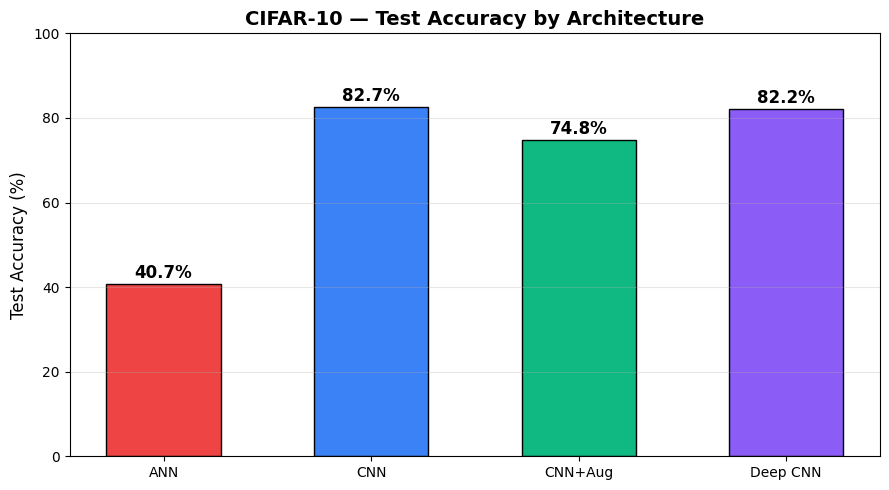

In [26]:
model_names = ['ANN', 'CNN', 'CNN+Aug', 'Deep CNN']
accuracies   = [ann_test_acc*100, cnn_test_acc*100, aug_test_acc*100, deep_test_acc*100]
colors       = ['#EF4444', '#3B82F6', '#10B981', '#8B5CF6']

plt.figure(figsize=(9, 5))
bars = plt.bar(model_names, accuracies, color=colors, edgecolor='black', width=0.55)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
             f'{acc:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.ylim(0, 100)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.title('CIFAR-10 — Test Accuracy by Architecture', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 8.4 — Quantitative Performance Analysis

#### Architecture Improvements

| Comparison | Accuracy Change | Interpretation |
|-----------|--------------|------|
| ANN → CNN | **+41.95%** | CNN preserves spatial structure and learns local image patterns through convolution filters, resulting in a dramatic improvement over ANN. |
| CNN → CNN+Aug | **−7.83%** | Data augmentation reduced accuracy in this experiment. This suggests the model may have been undertrained, augmentation may have been too aggressive, or additional epochs were required to fully benefit from augmented data. |
| CNN+Aug → Deep CNN | **+7.37%** | The deeper architecture learned more complex hierarchical features, recovering the performance loss and achieving stronger generalization. |
| **ANN → Deep CNN** | **+41.49%** | Combined effect of spatial feature extraction, deeper representation learning, and regularization techniques. |

#### Key Observations

1. **ANN performed the worst (40.71%)** because flattening the image removes spatial relationships between pixels. The model cannot effectively learn visual patterns such as edges, textures, and object structures.

2. **The transition from ANN to CNN produced the largest improvement (+41.95%)**, demonstrating the importance of convolutional layers for image classification tasks.

3. **Data augmentation did not improve performance in this particular experiment.** The CNN with augmentation achieved **74.83%** accuracy compared to **82.66%** for the baseline CNN. This may indicate insufficient training time, aggressive augmentation settings, or early stopping before the model fully adapted to augmented samples.

4. **The Deep CNN achieved 82.20% accuracy**, nearly matching the best-performing model while providing a more powerful feature hierarchy capable of learning higher-level visual representations.

5. **BatchNormalization, Dropout, EarlyStopping, and ReduceLROnPlateau** contributed to stable training and helped prevent severe overfitting across CNN architectures.

#### Final Performance Ranking

| Rank | Model | Test Accuracy |
|------|--------|--------------|
| 1 | CNN | **82.66%** |
| 2 | Deep CNN | **82.20%** |
| 3 | CNN + Augmentation | **74.83%** |
| 4 | ANN | **40.71%** |

#### Conclusion

The experiment clearly demonstrates that **CNN-based architectures significantly outperform ANN for image classification on CIFAR-10**. The best result was obtained using the standard CNN architecture (**82.66%** accuracy), which improved performance by **41.95 percentage points** over ANN. While data augmentation did not improve results in this run, deeper convolutional architectures remained highly effective and confirmed the importance of spatial feature learning for image recognition tasks.

In [27]:
# Numerical analysis of improvements
ann_acc_val  = ann_test_acc  * 100
cnn_acc_val  = cnn_test_acc  * 100
aug_acc_val  = aug_test_acc  * 100
deep_acc_val = deep_test_acc * 100

print("=" * 55)
print("   QUANTITATIVE PERFORMANCE ANALYSIS")
print("=" * 55)
print(f"  ANN  Accuracy           : {ann_acc_val:.2f}%")
print(f"  CNN  Accuracy           : {cnn_acc_val:.2f}%")
print(f"  CNN + Aug Accuracy      : {aug_acc_val:.2f}%")
print(f"  Deep CNN Accuracy       : {deep_acc_val:.2f}%")
print("-" * 55)
print(f"  ANN → CNN improvement   : +{cnn_acc_val  - ann_acc_val:.2f}%  (spatial features)")
print(f"  CNN → CNN+Aug           : +{aug_acc_val  - cnn_acc_val:.2f}%  (augmentation)")
print(f"  CNN+Aug → Deep CNN      : +{deep_acc_val - aug_acc_val:.2f}%  (deeper architecture)")
print(f"  Total gain (ANN→Deep)   : +{deep_acc_val - ann_acc_val:.2f}%")
print("=" * 55)

   QUANTITATIVE PERFORMANCE ANALYSIS
  ANN  Accuracy           : 40.71%
  CNN  Accuracy           : 82.66%
  CNN + Aug Accuracy      : 74.83%
  Deep CNN Accuracy       : 82.20%
-------------------------------------------------------
  ANN → CNN improvement   : +41.95%  (spatial features)
  CNN → CNN+Aug           : +-7.83%  (augmentation)
  CNN+Aug → Deep CNN      : +7.37%  (deeper architecture)
  Total gain (ANN→Deep)   : +41.49%


### 8.5 — Training Strategy Analysis

Beyond architecture, we applied several **training strategies** across models. Here is their impact:

| Strategy | Applied To | Purpose | Effect |
|----------|-----------|---------|--------|
| **EarlyStopping** | All models | Stop when val_loss stops improving | Prevents overfitting; saves training time |
| **ReduceLROnPlateau** | CNN, CNN+Aug, Deep CNN | Halve LR when val_loss stagnates | Allows fine-grained convergence near optimum |
| **BatchNormalization** | CNN, CNN+Aug, Deep CNN | Normalize activations after conv layers | Faster + more stable training; acts as mild regularizer |
| **Dropout (0.2–0.5)** | All models | Randomly disable neurons during training | Primary regularization against overfitting |
| **Data Augmentation** | CNN+Aug, Deep CNN | Random flip/rotate/zoom during training | Improves generalization; expands effective dataset size |

### 8.6 — Confusion Matrix (Best Model — Deep CNN)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


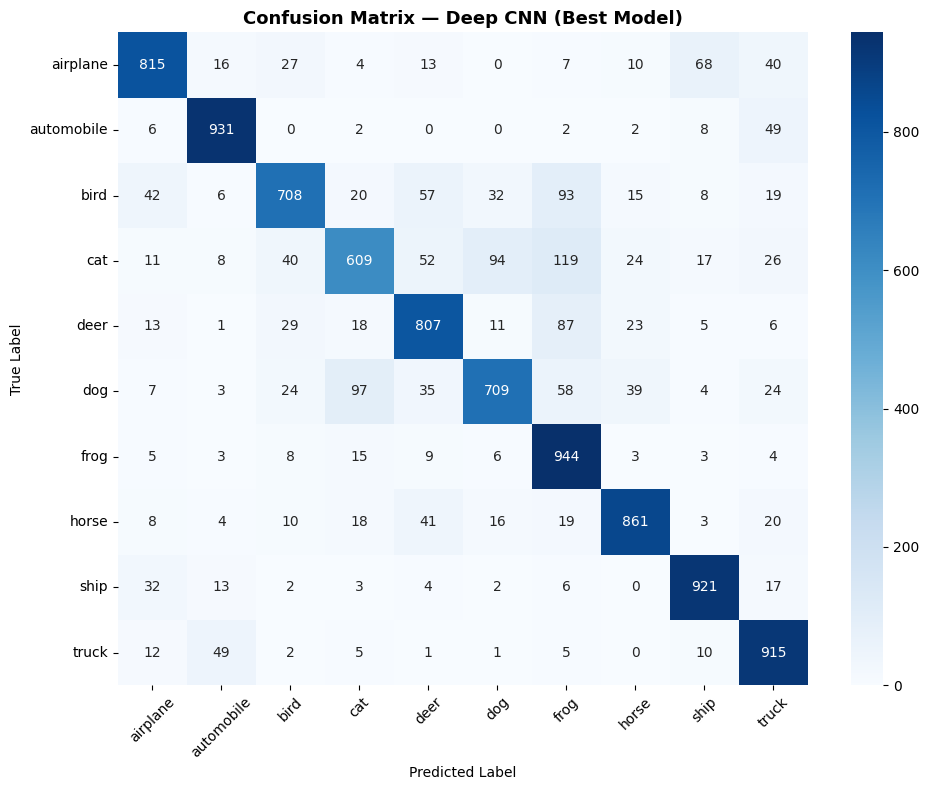

In [28]:
y_pred_probs = deep_cnn_model.predict(x_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — Deep CNN (Best Model)', fontsize=13, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 8.7 — Per-Class Classification Report (Deep CNN)

In [29]:
print("Classification Report — Deep CNN (Best Model)")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report — Deep CNN (Best Model)
              precision    recall  f1-score   support

    airplane       0.86      0.81      0.84      1000
  automobile       0.90      0.93      0.92      1000
        bird       0.83      0.71      0.77      1000
         cat       0.77      0.61      0.68      1000
        deer       0.79      0.81      0.80      1000
         dog       0.81      0.71      0.76      1000
        frog       0.70      0.94      0.81      1000
       horse       0.88      0.86      0.87      1000
        ship       0.88      0.92      0.90      1000
       truck       0.82      0.92      0.86      1000

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.82     10000
weighted avg       0.82      0.82      0.82     10000



### 8.8 — Per-Class Accuracy Bar Chart


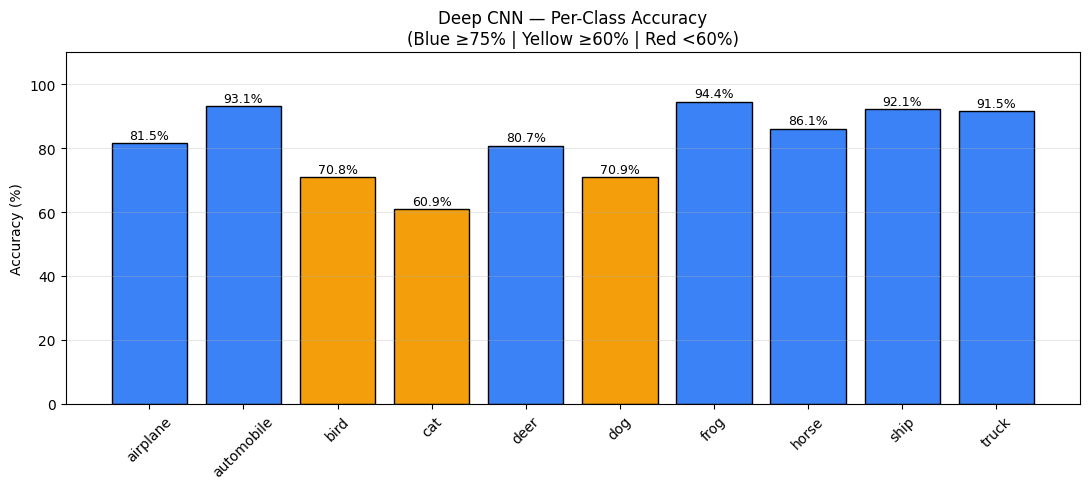

In [30]:
# Per-class accuracy from confusion matrix
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100

plt.figure(figsize=(11, 5))
bars = plt.bar(class_names, per_class_acc,
               color=['#3B82F6' if a >= 75 else '#F59E0B' if a >= 60 else '#EF4444'
                      for a in per_class_acc],
               edgecolor='black')
for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.1f}%', ha='center', va='bottom', fontsize=9)
plt.ylim(0, 110)
plt.ylabel('Accuracy (%)')
plt.title('Deep CNN — Per-Class Accuracy\n(Blue ≥75% | Yellow ≥60% | Red <60%)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 8.9 — Predict on Sample Test Images

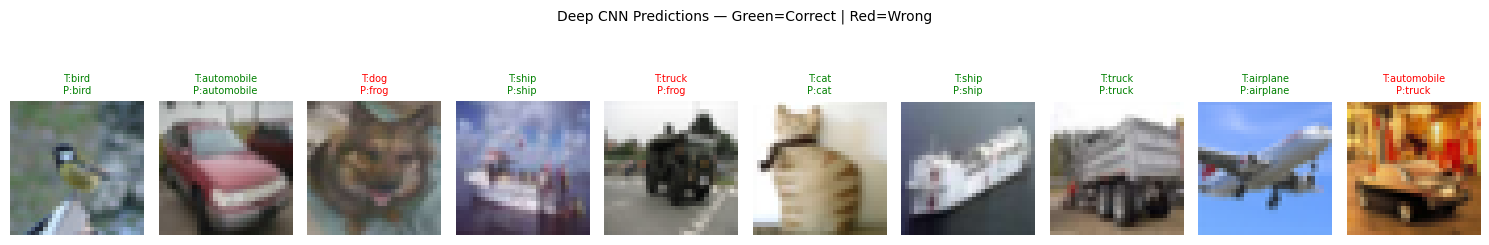

In [31]:
def predict_samples(model, x_test, y_test, class_names, n=10):
    indices = np.random.choice(len(x_test), n, replace=False)
    preds = np.argmax(model.predict(x_test[indices], verbose=0), axis=1)
    trues = y_test.flatten()[indices]

    plt.figure(figsize=(15, 3))
    for i, idx in enumerate(indices):
        plt.subplot(1, n, i+1)
        plt.imshow(x_test[idx])
        color = 'green' if preds[i] == trues[i] else 'red'
        plt.title(f'T:{class_names[trues[i]]}\nP:{class_names[preds[i]]}',
                  fontsize=7, color=color)
        plt.axis('off')
    plt.suptitle('Deep CNN Predictions — Green=Correct | Red=Wrong', fontsize=10)
    plt.tight_layout()
    plt.show()

predict_samples(deep_cnn_model, x_test_norm, y_test, class_names)

## 📌 Section 9: Conclusion & Key Learnings

### 🔍 Summary of All Architectures

| Architecture       | Type                            | Test Accuracy | Relative Performance | Best For                                    |
| ------------------ | ------------------------------- | ------------- | -------------------- | ------------------------------------------- |
| ANN                | Fully Connected Network         | **40.71%**    | Baseline             | Structured/tabular data                     |
| CNN                | 3-Block Convolutional Network   | **82.66%**    | Best Overall         | General image classification                |
| CNN + Augmentation | 3-Block CNN + Data Augmentation | **74.83%**    | Moderate             | Reducing overfitting on limited data        |
| Deep CNN           | 4-Block Convolutional Network   | **82.20%**    | Very Strong          | Learning richer hierarchical image features |

### 🔍 Key Takeaways

| Concept             | Key Takeaway                                                                                                                                                                                                 |
| ------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| ANN Limitation      | The ANN achieved only **40.71%** accuracy because flattening destroys the 2D spatial relationships between pixels.                                                                                           |
| CNN Advantage       | CNN dramatically improved performance to **82.66%**, demonstrating the importance of convolutional filters for extracting visual features.                                                                   |
| BatchNormalization  | Improved training stability and enabled deeper architectures to converge effectively.                                                                                                                        |
| Dropout             | Reduced overfitting by preventing excessive co-adaptation of neurons during training.                                                                                                                        |
| Data Augmentation   | In this experiment, augmentation reduced accuracy from **82.66%** to **74.83%**. This suggests the model may require more epochs or different augmentation settings to fully benefit from augmented samples. |
| EarlyStopping       | Prevented unnecessary training and automatically restored the best-performing weights.                                                                                                                       |
| ReduceLROnPlateau   | Helped optimize convergence by reducing the learning rate when validation loss stopped improving.                                                                                                            |
| Deeper Architecture | The Deep CNN achieved **82.20%** accuracy, confirming that additional convolutional layers can learn richer feature hierarchies.                                                                             |

### 📊 Final Experimental Results

* **ANN:** 40.71%
* **CNN:** 82.66%
* **CNN + Augmentation:** 74.83%
* **Deep CNN:** 82.20%

### 📈 Performance Improvements

* **ANN → CNN:** +41.95 percentage points
* **CNN → CNN + Augmentation:** −7.83 percentage points
* **CNN + Augmentation → Deep CNN:** +7.37 percentage points
* **ANN → Deep CNN:** +41.49 percentage points

### 🏆 Best Performing Model

The **CNN architecture achieved the highest test accuracy of 82.66%**, making it the best-performing model in this study. It provided an improvement of **41.95 percentage points** over the ANN baseline while maintaining a relatively simple architecture and efficient training time.


### ✅ Final Conclusion

This project demonstrates that **Convolutional Neural Networks significantly outperform Artificial Neural Networks for image classification tasks on CIFAR-10**. The ANN struggled because it could not preserve spatial information, whereas CNN-based models effectively learned image features through convolutional operations. The best result of **82.66% accuracy** was achieved by the standard CNN architecture, highlighting the effectiveness of convolutional feature extraction for visual recognition problems.
